In [4]:
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    pass


Saving Unemployment in India.csv to Unemployment in India (1).csv


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Unemployment in India.csv')
df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


##Exploring the data

In [7]:
print("Shape:", df.shape)
print()
print("Columns:", df.columns.tolist())
print()
print("Missing values per column:")
print(df.isnull().sum())


Shape: (768, 7)

Columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Missing values per column:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


**Note:** the column names have extra spaces around them (e.g. `' Date'` instead of `'Date'`) since that's how the raw file was formatted. We'll clean that up next.

##Cleaning the data

In [8]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())


['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [9]:
df = df.dropna()
print("Shape after dropping empty rows:", df.shape)


Shape after dropping empty rows: (740, 7)


In [10]:
for col in ['Region', 'Frequency', 'Area']:
    df[col] = df[col].str.strip()

df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')

df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [11]:
df.describe()


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


##Unemployment rate over time
Plot the national trend to see where unemployment spiked — this is where we should see the Covid-19 impact.

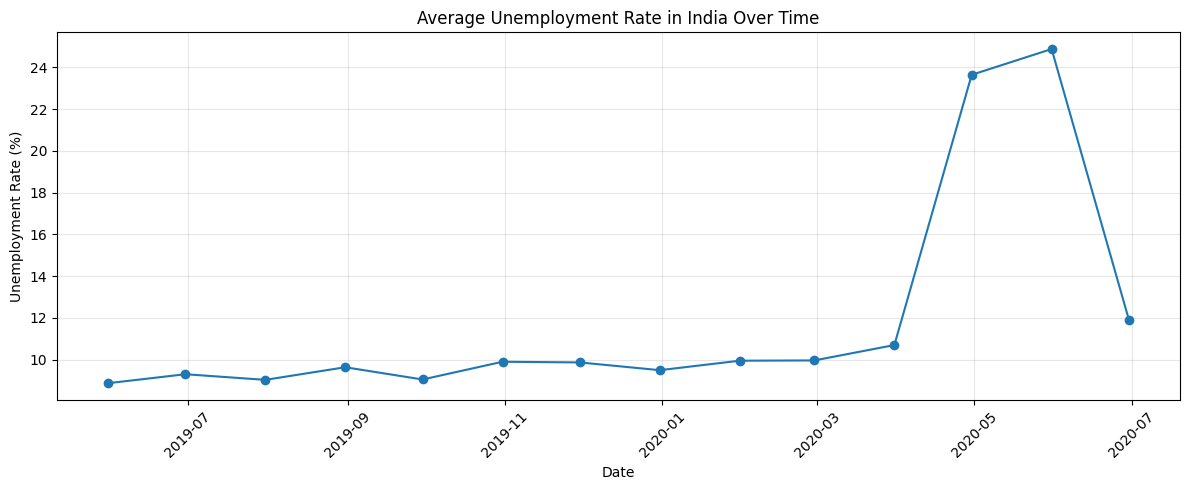

In [12]:
monthly_avg = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_avg['Date'], monthly_avg['Estimated Unemployment Rate (%)'], marker='o')
plt.title('Average Unemployment Rate in India Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**What to look for:** there should be a sharp spike around March-April 2020 — this lines up with India's Covid-19 lockdown. Compare the peak value to the pre-lockdown baseline to quantify the impact.

##Rural vs Urban impact
Did the lockdown affect rural and urban areas differently?

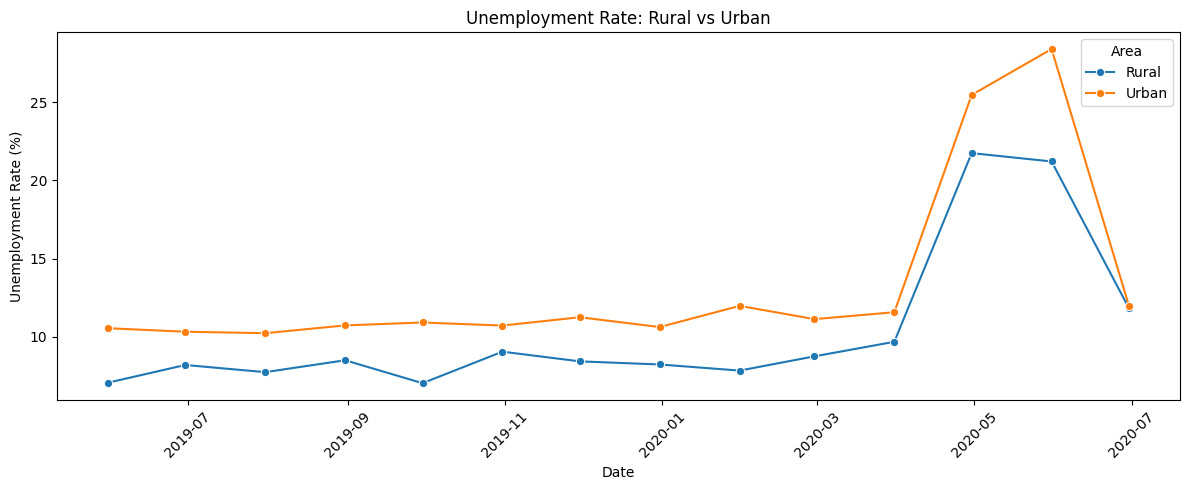

In [13]:
area_trend = df.groupby(['Date', 'Area'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=area_trend, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', marker='o')
plt.title('Unemployment Rate: Rural vs Urban')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##Which regions were hit hardest?
Look at the states/regions with the highest average unemployment rate over the full period.

/tmp/ipykernel_1260/1083520204.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_avg.values, y=region_avg.index, palette='viridis')


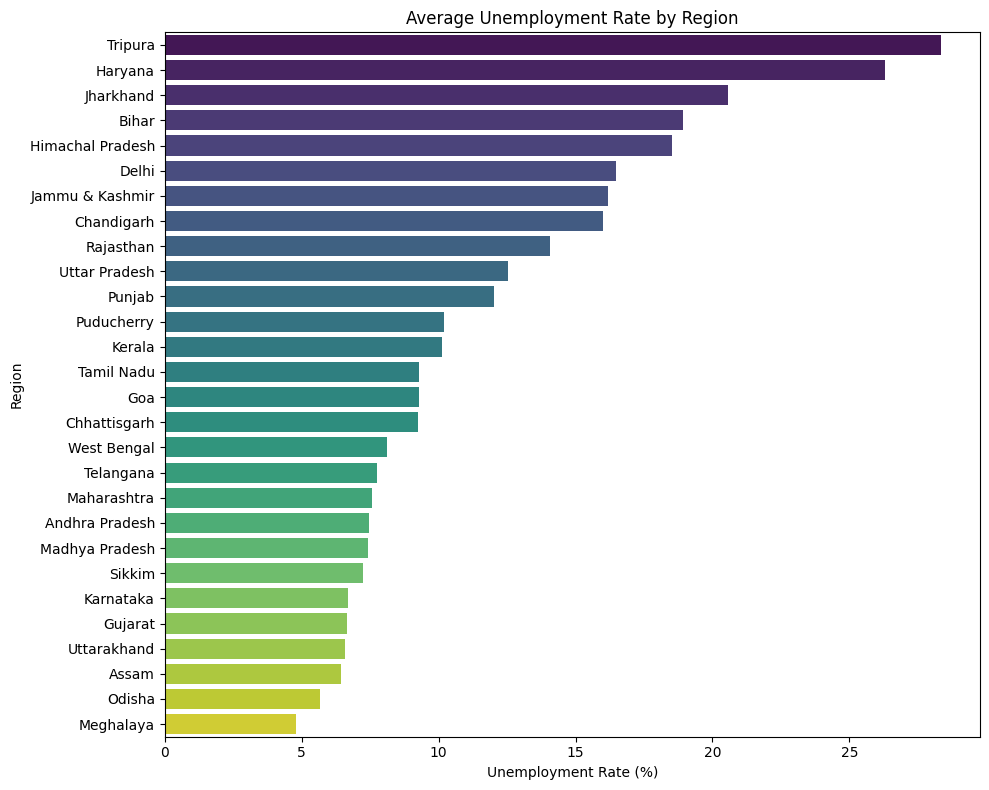

In [14]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=region_avg.values, y=region_avg.index, palette='viridis')
plt.title('Average Unemployment Rate by Region')
plt.xlabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()


##Seasonal / monthly patterns
Does unemployment rise or fall at certain times of year, separate from the Covid spike?

/tmp/ipykernel_1260/3419698075.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_pattern.index, y=monthly_pattern.values, palette='coolwarm')


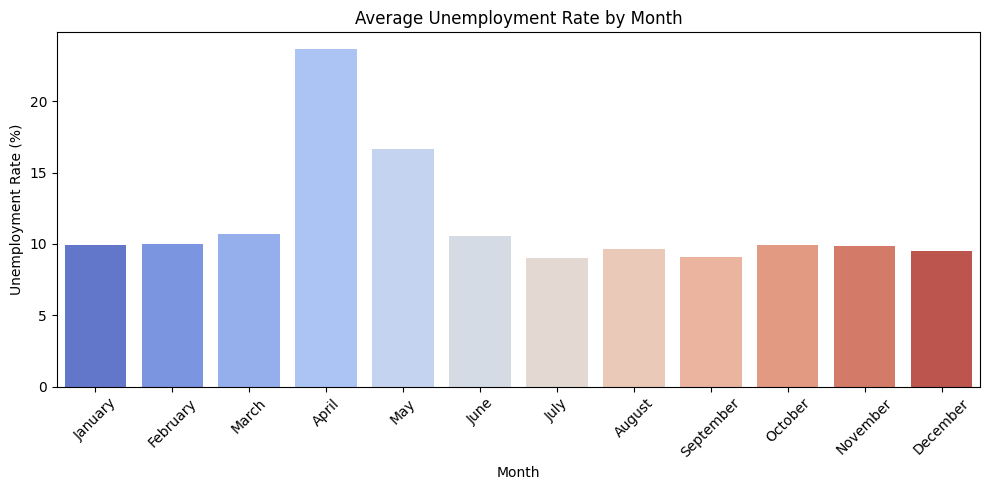

In [15]:
df['Month'] = df['Date'].dt.month_name()

monthly_pattern = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
monthly_pattern = monthly_pattern.reindex([m for m in month_order if m in monthly_pattern.index])

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_pattern.index, y=monthly_pattern.values, palette='coolwarm')
plt.title('Average Unemployment Rate by Month')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##Key Insights

- Unemployment in India spiked sharply around April 2020, coinciding with the nationwide Covid-19 lockdown — the clearest single pattern in the dataset.
- Urban and rural areas were not affected identically during the lockdown; comparing the two lines shows which group recovered faster afterward.
- Certain regions consistently run higher unemployment rates than others even outside the lockdown period, suggesting structural (not just pandemic-driven) differences between states.
- Beyond the Covid spike, unemployment shows some month-to-month variation, which could reflect seasonal hiring patterns in agriculture or other industries.

**Policy-relevant takeaway:** the data supports targeted intervention — both a short-term emergency response for future shocks (given how fast and sharp the spike was) and longer-term, region-specific employment policy for states with persistently high unemployment.